# 03 · Spectrograms and feature table

Reads the audio once and produces everything the modelling notebooks need.

| output | contents |
|---|---|
| `prepared/<config>/spectrograms.npy` | 100–2000 Hz spectrograms, one per 10-second clip |
| `prepared/<config>/groups.npy`, `meta.json` | recording index per clip, build settings |
| `merged_features.csv` | one row per clip: features, targets, environment, species counts |

`merged_features.csv` is the single source of truth for the targets. No separate label files are
written, so the neural nets and the tree models cannot diverge.

### Analysis band

Reef fish sound is concentrated below 2 kHz, so **all measurements are made on audio band-passed to
100–2000 Hz**, matching the spectrograms.

One column is an exception, carrying a `_fullband` suffix:

| column | reason |
|---|---|
| `zcr_fullband` | zero-crossing rate counts crossings per sample. Restricted to a narrow band it becomes close to a restatement of `centroid` rather than an independent measurement. |

### Before running

1. Notebook 01 must have completed, and all recordings should share one sample rate.
2. `Final_Fish_counts.csv` and `Temp_Wind_Data.csv` must be in `BASE`.
3. Set `REBUILD_AUDIO = True` on the first run.

In [1]:
# !pip install -q numpy pandas scipy librosa soundfile matplotlib

Recordings are taken from the fish count file. A recording with no fish data is skipped.

In [2]:
import os

BASE      = f"/scratch/{os.environ.get('USER','username')}/capstone"
FISH_FILE = f"{BASE}/Final_Fish_counts.csv"
MET_FILE  = f"{BASE}/Temp_Wind_Data.csv"
EXPORT_CSV = f"{BASE}/merged_features.csv"

# Anchoa is excluded from all diversity metrics. Dropped here if the fish file still contains it.
ANCHOA_MATCH = ["anchoa"]

REBUILD_AUDIO        = False   # re-read every .wav and recompute features (slow)
REBUILD_SPECTROGRAMS = False   # rebuild spectrogram configurations already on disk

print("project root:", os.path.basename(BASE.rstrip("/")) + "/")

project root: capstone/


## Settings

In [3]:
SR       = 6000          # spectrogram sample rate; Nyquist 3 kHz, clear of the band ceiling
BAND     = (100, 2000)   # analysis band for the spectrograms and all features
CLIP_SEC = 10
WINDOW   = "hann"
NORMALIZATION = "per_recording_p99_raw"

# (N_FFT, HOP) pairs for the spectrograms. A sweep across 32-341 ms windows found results
# insensitive to this choice, so one configuration is built. Add pairs to rebuild the comparison.
SWEEP = [
    (1024, 256),         # 170.7 ms window, 75% overlap
]

# ---- feature extraction, at the native sample rate ----
FEAT_NFFT   = 2048
BIN_WIDTH   = 100        # width of each power-spectrum bin, Hz
BIN_RANGE   = BAND       # bins span the analysis band
N_ADI_BANDS = 10
ADI_DB      = -50.0
ENV_SEC     = 0.0107     # envelope frame hop, in seconds
CLICK_MAD_K = 6.0        # click threshold, MADs above the median envelope
EVENT_DB    = 6.0        # event threshold, dB above the clip noise floor

N_BINS    = int((BIN_RANGE[1] - BIN_RANGE[0]) / BIN_WIDTH)
BIN_EDGES = [BIN_RANGE[0] + i*BIN_WIDTH for i in range(N_BINS + 1)]
BIN_COLS  = [f"pwr_{int(BIN_EDGES[i]):04d}_{int(BIN_EDGES[i+1]):04d}" for i in range(N_BINS)]
BAND_COLS = [("band_100_500", 100, 500), ("band_500_1000", 500, 1000),
             ("band_1000_2000", 1000, 2000)]
FULLBAND_COLS = ["zcr_fullband"]

PREPARED = os.path.join(BASE, "prepared")
CACHE    = os.path.join(PREPARED, "_clips_cache")
os.makedirs(CACHE, exist_ok=True)

def config_name(n_fft, hop): return f"nfft{n_fft}_hop{hop}"

print(f"analysis band: {BAND[0]}-{BAND[1]} Hz")
print(f"spectrograms : {[config_name(*c) for c in SWEEP]}")
print(f"power bins   : {N_BINS} x {BIN_WIDTH} Hz ({BIN_COLS[0]} ... {BIN_COLS[-1]})")
print(f"full-band    : {FULLBAND_COLS}")

analysis band: 100-2000 Hz
spectrograms : ['nfft1024_hop256']
power bins   : 19 x 100 Hz (pwr_0100_0200 ... pwr_1900_2000)
full-band    : ['zcr_fullband']


## Fish counts and environmental data

In [4]:
import numpy as np, pandas as pd, json, glob, re, time
from datetime import datetime
from scipy.special import gammaln
import matplotlib.pyplot as plt

def _read_any(path):
    for sep in [",", "\t", None]:
        try:
            d = pd.read_csv(path, sep=sep, engine="python")
            if d.shape[1] > 1: return d
        except Exception: continue
    return pd.read_csv(path)

fish = _read_any(FISH_FILE)
fish = fish.set_index(fish.columns[0]); fish.index = fish.index.astype(str).str.strip()
fish = fish.loc[:, [c for c in fish.columns if pd.api.types.is_numeric_dtype(fish[c])]]
fish = fish.apply(pd.to_numeric, errors="coerce").fillna(0.0).clip(lower=0)

anchoa_cols = [c for c in fish.columns if any(a in str(c).lower() for a in ANCHOA_MATCH)]
if anchoa_cols:
    print(f"[fish] dropping Anchoa column(s): {anchoa_cols}")
    fish = fish.drop(columns=anchoa_cols)
else:
    print("[fish] no Anchoa column present")
SPECIES = list(fish.columns)
WANTED  = set(fish.index)
print(f"[fish] {len(fish)} recordings x {len(SPECIES)} species")
allzero = [c for c in SPECIES if fish[c].sum() == 0]
if allzero:
    print(f"[fish] all-zero species column(s), exclude from any feature set: {allzero}")

met = _read_any(MET_FILE)
dt  = pd.to_datetime(met["DateTime"], format="mixed")
met["recording_key"] = (dt.dt.strftime("%Y-%m-%d") + " " +
                        np.where((dt.dt.hour >= 20) | (dt.dt.hour < 6), "Night", "Day"))
met = met.set_index("recording_key")[["SST_c", "WSPD_mps", "WDIR_deg"]]

miss = sorted(WANTED - set(met.index))
print(f"[met]  {len(met)} rows | missing for {len(miss)} fish recording(s)"
      + (f": {miss[:6]}" if miss else ""))
# 99 / 999 / 9999 are NDBC missing-data codes. Set them to NaN rather than filtering the rows,
# which would remove whole recordings.
for c, s in {"SST_c":[99.,999.,9999.], "WSPD_mps":[99.,999.,9999.],
             "WDIR_deg":[999.,9999.]}.items():
    bad = met[c].isin(s)
    if bad.any():
        print(f"[met]  {c}: {int(bad.sum())} sentinel(s) -> NaN  {list(met.index[bad])[:3]}")
        met.loc[bad, c] = np.nan
print(f"[met]  NaNs after cleaning: {met.isna().sum().to_dict()}")

[fish] no Anchoa column present
[fish] 72 recordings x 66 species
[fish] all-zero species column(s), exclude from any feature set: ['Aluterus schoepfii']
[met]  72 rows | missing for 0 fish recording(s)
[met]  NaNs after cleaning: {'SST_c': 0, 'WSPD_mps': 0, 'WDIR_deg': 0}


## Diversity targets

Diver survey counts vary in total effort between recordings, and both richness and Shannon rise with
effort. Rarefaction standardises this: each recording is described at a common sampling depth, set
to the smallest total count across recordings.

Richness uses the Hurlbert (1971) closed form. Shannon has no closed form and is estimated by Monte
Carlo over multivariate hypergeometric draws.

Anchoa is excluded before the depth is chosen.

In [5]:
RAREFY_DEPTH, RAREFY_REPS, RAREFY_SEED = None, 400, 0

def _lchoose(n, k): return gammaln(n+1.) - gammaln(k+1.) - gammaln(n-k+1.)

def rarefied_richness(counts, depth):
    """Expected species count in a random subsample of `depth` individuals, drawn without
    replacement. Hurlbert (1971)."""
    x = np.asarray(counts, float); x = x[x > 0]; N = float(x.sum())
    if N <= 0 or depth <= 0: return np.nan
    if depth >= N: return float(x.size)
    lp = np.full(x.shape, -np.inf); m = (N - x) >= depth
    lp[m] = _lchoose(N - x[m], depth) - _lchoose(N, depth)
    return float(np.sum(1.0 - np.exp(lp)))

def rarefied_shannon(counts, depth, reps=RAREFY_REPS, rng=None):
    """Expected Shannon index in a random subsample of `depth` individuals, drawn without
    replacement. Estimated over `reps` draws."""
    x = np.asarray(counts, float); x = x[x > 0]; N = float(x.sum())
    if N <= 0: return np.nan
    if depth >= N:
        p = x/N; return float(-(p*np.log(p)).sum())
    rng = np.random.default_rng(RAREFY_SEED) if rng is None else rng
    urn = np.rint(x).astype(np.int64); out = np.empty(reps)
    for r in range(reps):
        s = rng.multivariate_hypergeometric(urn, int(depth)).astype(float)
        s = s[s > 0]; p = s/s.sum(); out[r] = -(p*np.log(p)).sum()
    return float(out.mean())

totals = fish.sum(axis=1)
usable = totals > 0
DEPTH  = int(np.floor(totals[usable].min())) if RAREFY_DEPTH is None else int(RAREFY_DEPTH)
if not usable.all():
    print(f"[targets] {int((~usable).sum())} recording(s) have zero counts and receive NaN targets: "
          f"{list(totals.index[~usable])[:5]}")
print(f"[targets] totals: min {totals[usable].min():.0f} | median {totals[usable].median():.0f} "
      f"| max {totals[usable].max():.0f}")
print(f"[targets] rarefaction depth = {DEPTH}")
_rng = np.random.default_rng(RAREFY_SEED)
TARGETS = pd.DataFrame(index=fish.index)
TARGETS["total_abundance_no_anchoa"] = totals
TARGETS["richness_rare_no_anchoa"] = [rarefied_richness(fish.loc[k].values, DEPTH)
                                      if usable[k] else np.nan for k in fish.index]
TARGETS["shannon_rare_no_anchoa"]  = [rarefied_shannon(fish.loc[k].values, DEPTH, rng=_rng)
                                      if usable[k] else np.nan for k in fish.index]
print(TARGETS[["richness_rare_no_anchoa", "shannon_rare_no_anchoa"]]
      .describe().T[["min","mean","max","std"]].to_string())

[targets] totals: min 122 | median 1055 | max 3334
[targets] rarefaction depth = 122
                              min      mean        max       std
richness_rare_no_anchoa  5.680446  9.870012  18.466478  2.766192
shannon_rare_no_anchoa   0.699304  1.334489   2.171344  0.374322


## Feature extraction

All features are computed at the native sample rate on audio band-passed to `BAND`, except the three
`_fullband` columns which use the unfiltered signal. Frame sizes are specified in seconds, so a
change of recorder does not change the definitions.

| feature | definition |
|---|---|
| `RMS` | mean frame RMS |
| `Floor`, `Dynamics` | 5th percentile of frame dB, and 95th minus 5th |
| `Click_Count` | envelope peaks more than `CLICK_MAD_K` MADs above the median |
| `Click_Frequency` | mean spectral centroid of the frames containing clicks, in Hz |
| `Event_Count`, durations | runs of frames more than `EVENT_DB` above the noise floor |
| `centroid`, `bandwidth`, `rolloff` | spectral shape, 85% rolloff |
| `aci` | Acoustic Complexity Index: frame-to-frame change per bin, normalised by bin energy |
| `ADI` | Acoustic Diversity Index over `N_ADI_BANDS` sub-bands |
| `entropy` | spectral entropy, normalised to 0–1 |
| `band_*` | energy fraction in each named range; the three sum to 1 |
| `pwr_XXXX_YYYY` | energy fraction in each `BIN_WIDTH` Hz bin, named by its frequency range |

`aci` and `ADI` depend on the STFT settings above, so values are comparable within this table but
not against published figures.

`Click_Frequency` is 0 wherever no click was detected. That is a placeholder rather than a
measurement, so expect a spike at zero.

In [6]:
def _stft(y, sr):
    import librosa
    S = np.abs(librosa.stft(y, n_fft=FEAT_NFFT, hop_length=FEAT_NFFT//4,
                            win_length=FEAT_NFFT, window=WINDOW))**2
    f = librosa.fft_frequencies(sr=sr, n_fft=FEAT_NFFT)
    return S, f

def _adi(S, f, n_bands=N_ADI_BANDS, thr=ADI_DB):
    db = 10*np.log10(np.maximum(S, 1e-12)); db -= db.max()
    ed = np.linspace(f[0], f[-1], n_bands+1); pr = []
    for i in range(n_bands):
        m = (f >= ed[i]) & (f < ed[i+1] if i < n_bands-1 else f <= ed[i+1])
        pr.append(float((db[m] > thr).mean()) if m.any() else 0.0)
    p = np.asarray(pr); s = p.sum()
    if s <= 0: return 0.0
    p = p/s; p = p[p > 0]
    return float(-(p*np.log(p)).sum())

def _clicks(y, sr, S, f):
    """Click detection on the envelope, with the mean spectral centroid of the click frames.

    The threshold is relative (median + K x MAD), so it scales with the signal. Tested against
    synthetic clicks, band-passing changes the detected count by under 3%."""
    import librosa
    hop = max(1, int(round(ENV_SEC*sr)))
    rms = librosa.feature.rms(y=y, frame_length=2*hop, hop_length=hop)[0]
    med = np.median(rms); mad = np.median(np.abs(rms - med)) + 1e-12
    pk  = rms > med + CLICK_MAD_K*mad
    n   = int(np.sum(pk[1:] & ~pk[:-1]))
    hz  = 0.0
    if n and S.shape[1] > 1:
        idx = np.clip(((np.flatnonzero(pk) * hop) / (len(y) / S.shape[1])).astype(int),
                      0, S.shape[1] - 1)
        sub = S[:, np.unique(idx)]
        w = sub.sum(axis=0)
        if w.sum() > 0:
            hz = float(((f[:, None] * sub).sum(axis=0)[w > 0] / w[w > 0]).mean())
    return n, hz, rms, hop

def band_features(y, sr):
    """All features, on the band-limited clip at its native sample rate."""
    import librosa
    S, f = _stft(y, sr)
    m = (f >= BAND[0]) & (f <= BAND[1])
    S, f = S[m], f[m]
    tot, mag = S.sum(), np.sqrt(S)

    d = np.abs(np.diff(S, axis=1)).sum(axis=1); tt = S.sum(axis=1)
    p = S.mean(axis=1); ps = p.sum(); pn = p/ps if ps > 0 else p; pn = pn[pn > 0]
    out = dict(
        aci=float(np.sum(np.divide(d, tt, out=np.zeros_like(d), where=tt > 0))),
        entropy=float(-(pn*np.log(pn)).sum()/np.log(len(pn))) if len(pn) > 1 else 0.0,
        centroid=float(librosa.feature.spectral_centroid(S=mag, sr=sr, freq=f).mean()),
        bandwidth=float(librosa.feature.spectral_bandwidth(S=mag, sr=sr, freq=f).mean()),
        rolloff=float(librosa.feature.spectral_rolloff(S=mag, sr=sr, freq=f,
                                                       roll_percent=0.85).mean()),
        ADI=_adi(S, f))
    for name, lo, hi in BAND_COLS:
        mm = (f >= lo) & (f < hi)
        out[name] = float(S[mm].sum()/tot) if (tot > 0 and mm.any()) else 0.0
    for i, col in enumerate(BIN_COLS):
        mm = (f >= BIN_EDGES[i]) & (f < BIN_EDGES[i+1])
        out[col] = float(S[mm].sum()/tot) if (tot > 0 and mm.any()) else 0.0

    n_click, hz, rms, hop = _clicks(y, sr, S, f)
    db = 20*np.log10(np.maximum(rms, 1e-10))
    fl = float(np.percentile(db, 5))
    runs, r = [], 0
    for v in (db > fl + EVENT_DB):
        if v: r += 1
        elif r: runs.append(r); r = 0
    if r: runs.append(r)
    sec = hop/sr
    out.update(RMS=float(rms.mean()), Floor=fl,
               Dynamics=float(np.percentile(db, 95) - fl),
               Click_Count=n_click, Click_Frequency=hz,
               Event_Count=len(runs),
               Mean_Duration=float(np.mean(runs)*sec) if runs else 0.0,
               Max_Duration=float(np.max(runs)*sec) if runs else 0.0)
    return out

def fullband_features(y, sr):
    """Measurements taken on the unfiltered clip."""
    import librosa
    return dict(
        zcr_fullband=float(librosa.feature.zero_crossing_rate(
            y, frame_length=int(2*ENV_SEC*sr), hop_length=int(ENV_SEC*sr))[0].mean()))

## Audio processing

Each recording is read once. It is normalised, band-passed at its native rate, and resampled only
for the spectrograms. Features are computed on the band-limited signal at the native rate; the
band-limited 6 kHz clips are cached so spectrogram configurations can be rebuilt without re-reading
audio.

In [7]:
DATE_RE = re.compile(r"(\d{6})-(\d{4})")
CLIP_LEN = CLIP_SEC * SR

def parse_meta(path):
    m = DATE_RE.search(os.path.basename(path))
    dt = datetime.strptime(m.group(1)+m.group(2), "%y%m%d%H%M") if m else datetime(2025,1,1)
    return dt, (dt.hour >= 20 or dt.hour < 6)

def rec_key(dt, night): return f"{dt.strftime('%Y-%m-%d')} {'Night' if night else 'Day'}"

def season_of(d):
    return {12:"Winter",1:"Winter",2:"Winter",3:"Spring",4:"Spring",5:"Spring",
            6:"Summer",7:"Summer",8:"Summer",9:"Fall",10:"Fall",11:"Fall"}[d.month]

def build_audio(force=False):
    bin_p  = os.path.join(CACHE, "clips.f32")
    feat_p = os.path.join(CACHE, "clip_features.csv")
    meta_p = os.path.join(CACHE, "cache_meta.json")
    if not force and all(os.path.exists(p) for p in (bin_p, feat_p, meta_p)):
        cm = json.load(open(meta_p))
        clips = np.memmap(bin_p, dtype=np.float32, mode="r",
                          shape=(cm["n_clips"], cm["clip_len"]))
        F = pd.read_csv(feat_p)
        print(f"[audio] cache: {clips.shape} | {cm['n_recordings']} recordings | "
              f"features {F.shape} | sample rates {cm['sample_rates']}")
        print("        (REBUILD_AUDIO=True to re-read)")
        return dict(clips=clips, features=F, **{k: cm[k] for k in
                    ("groups_list","rec_order","files","n_clips","sample_rates")})

    import librosa
    from scipy.signal import butter, sosfiltfilt

    def normalize(y):
        """Divide the whole recording by the 99th percentile of its raw amplitude.

        One divisor per recording, applied before filtering. This removes recorder gain differences
        between recordings while preserving loud-versus-quiet contrast between clips of the same
        recording."""
        ref = float(np.percentile(np.abs(y), 99.0))
        if ref < 1e-9: ref = float(np.max(np.abs(y)))
        return (y/ref).astype(np.float32) if ref > 1e-9 else y.astype(np.float32)

    wavs = sorted(glob.glob(os.path.join(BASE,"audio","**","*.wav"), recursive=True) +
                  glob.glob(os.path.join(BASE,"audio","**","*.WAV"), recursive=True))
    if not wavs: raise SystemExit(f"no .wav under {BASE}/audio")
    wavs = sorted(wavs, key=lambda p: parse_meta(p)[0])
    print(f"[audio] {len(wavs)} wav files | reading")

    keys, files, rows, rates, used, skipped, n_clips = [], {}, [], {}, set(), [], 0
    t0 = time.time()
    with open(bin_p, "wb") as fh:
        for path in wavs:
            dt, night = parse_meta(path); key = rec_key(dt, night)
            if key not in WANTED:
                skipped.append(os.path.basename(path)); continue
            y_raw, sr0 = librosa.load(path, sr=None, mono=True)
            rates[sr0] = rates.get(sr0, 0) + 1
            y_raw  = normalize(y_raw)
            y_fish = sosfiltfilt(butter(4, list(BAND), btype="band", fs=sr0,
                                        output="sos"), y_raw).astype(np.float32)
            y_6k   = (librosa.resample(y_fish, orig_sr=sr0, target_sr=SR)
                      if sr0 != SR else y_fish).astype(np.float32)
            raw_len = CLIP_SEC * sr0
            n_this = min(len(y_6k)//CLIP_LEN, len(y_raw)//raw_len)
            for i in range(n_this):
                c6 = y_6k[i*CLIP_LEN:(i+1)*CLIP_LEN]
                fh.write(np.ascontiguousarray(c6, dtype=np.float32).tobytes())
                sl = slice(i*raw_len, (i+1)*raw_len)
                r = band_features(y_fish[sl], sr0)
                r.update(fullband_features(y_raw[sl], sr0))
                rows.append(r); keys.append(key); n_clips += 1
            used.add(key); files[key] = os.path.basename(path)
            print(f"  {key:24s} {os.path.basename(path):26s} sr={sr0:>6d} clips={n_this}")

    rec_order = list(dict.fromkeys(keys))
    gid = {k:i for i,k in enumerate(rec_order)}
    groups = [gid[k] for k in keys]
    F = pd.DataFrame(rows); F.insert(0, "recording_key", keys)
    F.to_csv(feat_p, index=False)

    if skipped: print(f"\n[audio] skipped {len(skipped)} wav(s) with no fish data: {skipped[:6]}")
    for m in sorted(WANTED - used): print("   MISSING (fish data but no wav):", m)
    print(f"[audio] {len(used)} / {len(WANTED)} recordings with fish data have audio")
    print(f"[audio] sample rates: {rates}")
    if len(rates) > 1:
        print("        WARNING: more than one sample rate. The _fullband columns are not "
              "comparable across rates; resample to a common rate.")

    json.dump(dict(n_clips=n_clips, clip_len=CLIP_LEN, SR=SR, BAND=list(BAND), CLIP_SEC=CLIP_SEC,
                   normalization=NORMALIZATION, n_recordings=len(rec_order), rec_order=rec_order,
                   files=files, groups_list=groups,
                   sample_rates={str(k):v for k,v in rates.items()}),
              open(meta_p, "w"), indent=2)
    clips = np.memmap(bin_p, dtype=np.float32, mode="r", shape=(n_clips, CLIP_LEN))
    print(f"\n[audio] {n_clips} clips ({os.path.getsize(bin_p)/1e9:.2f} GB) in "
          f"{(time.time()-t0)/60:.1f} min")
    return dict(clips=clips, features=F, groups_list=groups, rec_order=rec_order,
                files=files, n_clips=n_clips, sample_rates={str(k):v for k,v in rates.items()})

## Spectrograms

Built from the cached band-limited clips. This is the only step that depends on `(N_FFT, HOP)`.

In [8]:
def build_spectrograms(n_fft, hop, cache, force=False, chunk=256):
    import librosa
    name = config_name(n_fft, hop)
    prep = os.path.join(PREPARED, name); os.makedirs(prep, exist_ok=True)
    spec_p, grp_p, meta_p = (os.path.join(prep,f) for f in
                             ("spectrograms.npy","groups.npy","meta.json"))
    if not force and all(os.path.exists(p) for p in (spec_p, grp_p, meta_p)):
        meta = json.load(open(meta_p))
        if meta.get("N_FFT") == n_fft and meta.get("HOP") == hop:
            print(f"[{name}] cached: {meta['n_clips']} x {meta['n_freq']} x {meta['n_time']}")
            return meta
    freqs = librosa.fft_frequencies(sr=SR, n_fft=n_fft)
    fmask = (freqs >= BAND[0]) & (freqs <= BAND[1])
    n_freq, n_time, n = int(fmask.sum()), 1 + CLIP_LEN//hop, cache["n_clips"]
    print(f"[{name}] building {n} x {n_freq} x {n_time} "
          f"({n*n_freq*n_time*4/1e9:.2f} GB)", flush=True)
    t0 = time.time()
    out = np.lib.format.open_memmap(spec_p, mode="w+", dtype=np.float32,
                                    shape=(n, n_freq, n_time))
    for i in range(0, n, chunk):
        blk = np.asarray(cache["clips"][i:i+chunk], dtype=np.float32)
        for j, c in enumerate(blk):
            S = np.abs(librosa.stft(c, n_fft=n_fft, hop_length=hop,
                                    win_length=n_fft, window=WINDOW))**2
            # top_db=None keeps the dB scale absolute. The librosa default would clip each clip
            # relative to its own maximum, giving loud and quiet clips different floors.
            out[i+j] = librosa.power_to_db(S[fmask], ref=1.0, top_db=None).astype(np.float32)
        if (i//chunk) % 4 == 0: print(f"    {min(i+chunk,n)}/{n}", end="\r", flush=True)
    out.flush(); del out
    np.save(grp_p, np.asarray(cache["groups_list"], dtype=np.int64))
    meta = dict(config_name=name, SR=SR, BAND=list(BAND), CLIP_SEC=CLIP_SEC, N_FFT=n_fft, HOP=hop,
                WIN=n_fft, WINDOW=WINDOW, n_freq=n_freq, n_time=n_time, bin_hz=SR/n_fft,
                col_ms=1000.*hop/SR, win_ms=1000.*n_fft/SR, overlap_pct=100.*(1-hop/n_fft),
                power_to_db_top_db=None, n_recordings=len(cache["rec_order"]), n_clips=n,
                rec_order=cache["rec_order"], normalization=NORMALIZATION, freq_scale="linear",
                targets_source=os.path.basename(EXPORT_CSV))
    json.dump(meta, open(meta_p,"w"), indent=2)
    print(f"    done in {(time.time()-t0)/60:.1f} min -> {os.path.relpath(prep, BASE)}/          ")
    return meta

## Preview

Plots one clip per configuration for visual inspection. `PREVIEW_PCT` selects by energy percentile;
raise it toward 1.0 for a louder clip, lower it toward 0.5 for a typical one.

In [9]:
PREVIEW_IDX, PREVIEW_PCT, CMAP = None, 0.75, "magma"

def pick_preview(cache, pct=PREVIEW_PCT, chunk=256):
    n = cache["n_clips"]; r = np.empty(n)
    for i in range(0, n, chunk):
        b = np.asarray(cache["clips"][i:i+chunk], dtype=np.float32)
        r[i:i+len(b)] = np.sqrt((b**2).mean(axis=1))
    o = np.argsort(r); return int(o[min(len(o)-1, int(pct*(len(o)-1)))])

def preview(meta, idx, cache, show=True):
    prep = os.path.join(PREPARED, meta["config_name"])
    S = np.asarray(np.load(os.path.join(prep,"spectrograms.npy"), mmap_mode="r")[idx], np.float32)
    w = np.asarray(cache["clips"][idx], np.float32)
    key = cache["rec_order"][cache["groups_list"][idx]]
    fig,(a0,a1) = plt.subplots(2,1,figsize=(12,5.4),sharex=True,
                               gridspec_kw=dict(height_ratios=[1,4],hspace=0.08))
    a0.plot(np.arange(len(w))/SR, w, lw=0.4, color="0.25"); a0.set_xlim(0,CLIP_SEC)
    a0.set_ylabel("amp"); a0.grid(alpha=0.25)
    a0.set_title(f"{meta['config_name']} — {meta['win_ms']:.1f} ms window, "
                 f"{meta['bin_hz']:.2f} Hz bins\nclip {idx} of {key} — "
                 f"{meta['n_freq']} x {meta['n_time']}", fontsize=10)
    im = a1.imshow(S, origin="lower", aspect="auto", cmap=CMAP,
                   vmin=np.percentile(S,20), vmax=np.percentile(S,99),
                   extent=[0,CLIP_SEC,BAND[0],BAND[1]], interpolation="nearest")
    a1.set_xlabel("Time (s)"); a1.set_ylabel("Frequency (Hz)")
    fig.colorbar(im, ax=[a0,a1], label="Power (dB)", pad=0.01)
    fig.savefig(os.path.join(prep,"preview.png"), dpi=140, bbox_inches="tight")
    if show: plt.show()
    plt.close(fig)

## Run

[audio] 75 wav files | reading
  2025-05-27 Night         00-250527-2226.wav         sr= 44100 clips=60
  2025-06-02 Day           00-250602-1320.wav         sr= 48000 clips=18
  2025-06-02 Night         00-250602-2230.wav         sr= 48000 clips=18
  2025-06-09 Day           00-250609-1238.wav         sr= 44100 clips=40
  2025-06-09 Night         00-250609-2140.wav         sr= 44100 clips=40
  2025-06-16 Night         00-250616-2130.wav         sr= 44100 clips=39
  2025-06-23 Day           00-250623-1245.wav         sr= 44100 clips=40
  2025-06-23 Night         00-250623-2145.wav         sr= 44100 clips=39
  2025-06-30 Day           00-250630-1230.wav         sr= 44100 clips=39
  2025-06-30 Night         00-250630-2130.wav         sr= 44100 clips=40
  2025-07-07 Day           00-250707-1230.wav         sr= 44100 clips=39
  2025-07-07 Night         00-250707-2145.wav         sr= 44100 clips=39
  2025-07-28 Night         00-250728-2130.wav         sr= 44100 clips=39
  2025-08-04 Day    

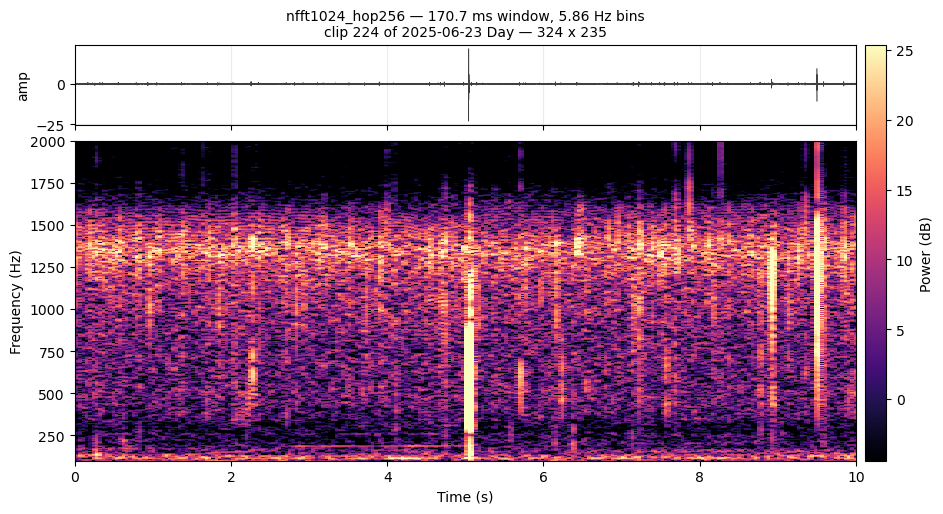

In [10]:
cache = build_audio(force=REBUILD_AUDIO)
if PREVIEW_IDX is None: PREVIEW_IDX = pick_preview(cache)
print(f"\npreview clip {PREVIEW_IDX} ({PREVIEW_PCT:.0%} energy percentile), from "
      f"{cache['rec_order'][cache['groups_list'][PREVIEW_IDX]]}")
built = []
for n_fft, hop in SWEEP:
    print(f"\n{'='*70}")
    m = build_spectrograms(n_fft, hop, cache, force=REBUILD_SPECTROGRAMS)
    preview(m, PREVIEW_IDX, cache); built.append(m)

## Feature table

One row per clip. Species counts, diversity targets and environmental readings are recording-level
values repeated across that recording's clips. Columns are grouped by what they measure.

In [11]:
keys = [cache["rec_order"][g] for g in cache["groups_list"]]
starts, prev, c = [], None, 0
for k in keys:
    c = 0 if k != prev else c + 1
    starts.append(c*CLIP_SEC); prev = k

M = pd.DataFrame({"Filename": [cache["files"].get(k,"") for k in keys],
                  "recording_key": keys, "window_start_sec": starts})
M["date"]        = M["recording_key"].str.split().str[0]
M["collection"]  = M["recording_key"].str.split().str[1].str.lower()
M["Time_of_day"] = np.where(M["collection"] == "night", "n", "d")
M["Season"]      = pd.to_datetime(M["date"]).map(season_of)
for c_ in ["SST_c","WSPD_mps","WDIR_deg"]: M[c_] = M["recording_key"].map(met[c_])

FEAT = cache["features"].drop(columns=["recording_key"], errors="ignore").reset_index(drop=True)
M = pd.concat([M.reset_index(drop=True), FEAT], axis=1)
for s in SPECIES: M[s] = M["recording_key"].map(fish[s])
for t in ["shannon_rare_no_anchoa", "richness_rare_no_anchoa", "total_abundance_no_anchoa"]:
    M[t] = M["recording_key"].map(TARGETS[t])

ORDER = (
    ["Filename", "recording_key", "date", "collection", "Time_of_day", "Season",
     "window_start_sec"]
    + ["SST_c", "WSPD_mps", "WDIR_deg"]
    + ["RMS", "Floor", "Dynamics"]
    + ["Click_Count", "Click_Frequency", "Event_Count", "Mean_Duration", "Max_Duration"]
    + ["centroid", "bandwidth", "rolloff"]
    + ["aci", "ADI", "entropy"]
    + [c for c, _, _ in BAND_COLS]
    + BIN_COLS
    + FULLBAND_COLS
    + SPECIES
    + ["shannon_rare_no_anchoa", "richness_rare_no_anchoa", "total_abundance_no_anchoa"])
missing = [c for c in ORDER if c not in M.columns]
if missing: raise SystemExit(f"columns missing from the export: {missing}")
M[ORDER].to_csv(EXPORT_CSV, index=False)
print(f"[export] {os.path.relpath(EXPORT_CSV, BASE)}")
print(f"         {len(M)} clip rows | {M['recording_key'].nunique()} recordings | "
      f"{len(ORDER)} columns | {os.path.getsize(EXPORT_CSV)/1e6:.1f} MB")

[export] merged_features.csv
         2670 clip rows | 72 recordings | 116 columns | 2.6 MB


## Summary

In [12]:
print(f"recordings {M['recording_key'].nunique()} | clips {len(M)} | "
      f"{len(M)/M['recording_key'].nunique():.1f} per recording")
print(f"rarefaction depth {DEPTH} on {len(SPECIES)} species | sample rates {cache['sample_rates']}")
print()
T = M.groupby("recording_key").first()
for t in ["shannon_rare_no_anchoa", "richness_rare_no_anchoa"]:
    v = T[t].dropna()
    print(f"{t:26s} {v.min():.3f} - {v.max():.3f} | mean {v.mean():.3f} | sd {v.std():.3f} "
          f"| mean-baseline MAE {np.abs(v-v.mean()).mean():.4f}")
print()
chk = ["RMS","Floor","Dynamics","Click_Count","Click_Frequency","Event_Count",
       "centroid","bandwidth","rolloff","aci","ADI","entropy"] + FULLBAND_COLS
with pd.option_context("display.float_format", lambda v: f"{v:.4g}"):
    print(M[chk].describe().T[["mean","std","min","max"]].to_string())
print()
b = M[BIN_COLS].sum(axis=1); bd = M[[c for c,_,_ in BAND_COLS]].sum(axis=1)
print(f"{N_BINS} power bins of {BIN_WIDTH} Hz over {BIN_RANGE[0]}-{BIN_RANGE[1]} Hz")
print(f"  bins sum to {b.mean():.3f}, band fractions to {bd.mean():.3f} (both should be ~1)")
top = M[BIN_COLS].mean().sort_values(ascending=False).head(5)
print("  strongest: " + ", ".join(f"{k.replace('pwr_','')} ({v:.3f})" for k, v in top.items()))
print()
print(f"\nanalysis band {BAND[0]}-{BAND[1]} Hz; full-band columns: {FULLBAND_COLS}")
print(f"Next: 04_train_cnn.ipynb and 05_train_rnn.ipynb read targets from "
      f"{os.path.basename(EXPORT_CSV)}.")

recordings 72 | clips 2670 | 37.1 per recording
rarefaction depth 122 on 66 species | sample rates {'44100': 70, '48000': 2}

shannon_rare_no_anchoa     0.699 - 2.171 | mean 1.334 | sd 0.374 | mean-baseline MAE 0.3005
richness_rare_no_anchoa    5.680 - 18.466 | mean 9.870 | sd 2.766 | mean-baseline MAE 2.1455

                  mean     std     min    max
RMS             0.1437 0.09065 0.02108 0.4212
Floor            -26.7   11.22    -200 -11.95
Dynamics         14.11     9.5   3.664  189.4
Click_Count      27.01   19.73       0    112
Click_Frequency   1057   252.2       0   1455
Event_Count       74.8   31.49       0    201
centroid         973.4   141.7   500.6   1293
bandwidth        418.8    57.8     276  570.5
rolloff           1389     139   772.4   1784
aci              84.83   10.58   61.81  113.2
ADI              2.195  0.1342   1.402  2.303
entropy          0.795 0.07588  0.5303 0.9673
zcr_fullband    0.1465  0.0915 0.02327 0.5258

19 power bins of 100 Hz over 100-2000 Hz
  